# YOLOv1 — Redmon et al. (2016), explained

Paper: *You Only Look Once: Unified, Real-Time Object Detection*.

Goal of this notebook: **understand YOLO's single-shot detection design**, not to build a framework.
Anything PyTorch already provides (`nn.Conv2d`, `nn.BatchNorm2d`, `SGD`, `DataLoader`) is used as-is.

Here the paper's PASCAL VOC task (20 object classes) is swapped for **tiger detection** on the
[ATRW](https://cvwc2019.github.io/challenge.html) detection dataset: given a photo, find every
tiger in it and draw a box around each one.

**Layout**
1. Load the data
2. Helper functions, and why each one exists
3. The architecture — grid, boxes, confidence, and the training step line by line
4. Train
5. Predict and validate
6. Glossary

**What the paper specifies** (kept): the S×S grid of "responsible" cells, B boxes + confidence per
cell, leaky ReLU (slope 0.1) on hidden layers, the multi-part sum-squared loss with λcoord=5,
λnoobj=0.5 and square-root width/height, and greedy non-max suppression at inference.

**Where this adapts** (four places, on purpose):
- Paper predicts C=20 PASCAL classes per cell. Here: C=1 (**Tiger** only — ATRW's detection set has
  a single class), so the class term of the loss and the leaderboard metric (mAP) both collapse to
  one number: AP for "Tiger".
- Paper pretrains the first 20 conv layers on ImageNet for a week, then fine-tunes for detection.
  Here we skip pretraining and train the detector end-to-end from random init, same as every other
  notebook in this series.
- Paper's full network has 24 conv layers; we use the paper's own **Fast YOLO** shape (9 conv layers,
  fewer filters) so a full training run is practical on this dataset and hardware — same trade-off
  as the ResNet-18-style choice in `n4`.
- Paper's final layer is plain linear, relying on ImageNet-pretrained features plus careful LR
  warmup to keep raw box regression targets sane. From random init that combination is missing, and
  a linear head measurably diverges (confirmed while building this notebook: loss explodes past
  1e18 within two epochs). We bound the final layer with a **sigmoid** instead — which just enforces
  the range the paper already assigns x, y, w, h and confidence (all "fall between 0 and 1", Sec 2.2)
  through the activation rather than hoping unconstrained optimization finds it unaided.


# Section 1 — Loading the data

**ATRW (Amur Tiger Re-identification in the Wild), detection split**: full video-frame photos, each
tagged with one or more tiger bounding boxes.

```
benchmarks/atrw_dataset_detection_tiger/
├── Annotations/*.xml              PASCAL-VOC-style box labels, one file per image
├── trainval/*.jpg                 2,762 labelled images (same ids as Annotations)
├── test/*.jpg                     1,652 images — official test set, unlabelled leaderboard set
└── ImageSets/Main/{train,val,trainval}.txt   ready-made id lists (2,485 / 277 / 2,762)
```

Two details this notebook works around:
- The official `test/` folder has no annotations (it's held back for the challenge leaderboard, not
  local evaluation). So "test" here means the **val split** the dataset ships in `ImageSets/Main/`
  — 277 images already held out from the 2,485 in `train.txt`. (Same situation as the ATRW re-ID
  split in `n4`; we keep the `test_ds` / `test_loader` names for consistency with that notebook.)
- Each image can hold **multiple tigers** (up to 10 in one frame) at full 1920×1080 resolution — the
  "spatially separated bounding boxes" setting the paper is built for, unlike the single-object
  classification datasets used in `n1`–`n4`.

Paper resizes every image to 448×448 for the network; we do the same, with box coordinates resized
along with it. A direct (non-aspect-preserving) resize keeps the coordinate math simple — no
letterbox padding to track — and the aspect distortion from 1920×1080 → 448×448 is mild.


In [1]:
import os
import random
import xml.etree.ElementTree as ET
from pathlib import Path

import torch
from torch import nn
import torch.nn.functional as F
from PIL import Image, ImageFile
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

# Prevent worker crashes on partially corrupted JPEG files.
ImageFile.LOAD_TRUNCATED_IMAGES = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True

torch.manual_seed(0)
random.seed(0)

DATA_ROOT = Path("benchmarks/atrw_dataset_detection_tiger")
IMG_DIR = DATA_ROOT / "trainval"
ANN_DIR = DATA_ROOT / "Annotations"
SPLIT_DIR = DATA_ROOT / "ImageSets" / "Main"

CLASSES = ["Tiger"]
N_CLASSES = len(CLASSES)

print("torch", torch.__version__, "| device:", DEVICE)


torch 2.12.1+cu126 | device: cuda


In [2]:
IMG_SIZE = 448
S, B, C = 7, 2, N_CLASSES        # 7x7 grid, 2 candidate boxes/cell, 1 class ("Tiger")
CELL = IMG_SIZE / S              # pixels per grid cell at 448 resolution


def read_split(name):
    """train / val / trainval -> list of image ids, e.g. '0131'."""
    with open(SPLIT_DIR / f"{name}.txt") as f:
        return [line.strip() for line in f if line.strip()]


def parse_boxes(image_id):
    """Annotation XML -> (list of (xmin,ymin,xmax,ymax), orig_w, orig_h). Every box is class Tiger."""
    root = ET.parse(ANN_DIR / f"{image_id}.xml").getroot()
    w = int(root.find("size/width").text)
    h = int(root.find("size/height").text)
    boxes = []
    for obj in root.findall("object"):
        b = obj.find("bndbox")
        boxes.append((
            float(b.find("xmin").text), float(b.find("ymin").text),
            float(b.find("xmax").text), float(b.find("ymax").text),
        ))
    return boxes, w, h


def resize_boxes(boxes, orig_w, orig_h, size=IMG_SIZE):
    """Rescale pixel boxes from the original image size into size x size space."""
    sx, sy = size / orig_w, size / orig_h
    return [(x0 * sx, y0 * sy, x1 * sx, y1 * sy) for x0, y0, x1, y1 in boxes]


def encode_target(boxes, size=IMG_SIZE):
    """
    Boxes (xmin,ymin,xmax,ymax) in `size`-pixel space -> (S,S,5+C) grid target.
    Cell (row,col) is "responsible" if the box CENTER falls in it (paper, Sec 2).
    x,y are stored as offsets within the cell (0..1); w,h as fractions of the whole image —
    exactly the parametrization the paper trains against (Sec 2.2).
    If two boxes share a cell, the later one overwrites: YOLO can only hold one object per
    cell, a limitation the paper names directly (Sec 2.4) and that matters here since ATRW
    frames can hold up to 10 tigers.
    """
    target = torch.zeros(S, S, 5 + C)
    for x0, y0, x1, y1 in boxes:
        xc, yc = (x0 + x1) / 2, (y0 + y1) / 2
        bw, bh = (x1 - x0) / size, (y1 - y0) / size
        col, row = int(xc // CELL), int(yc // CELL)
        col, row = min(max(col, 0), S - 1), min(max(row, 0), S - 1)
        x_cell = (xc - col * CELL) / CELL
        y_cell = (yc - row * CELL) / CELL
        target[row, col, 0] = 1.0                        # objectness
        target[row, col, 1:5] = torch.tensor([x_cell, y_cell, bw, bh])
        target[row, col, 5] = 1.0                         # class Tiger (only class -> always 1)
    return target


def grid_to_boxes(target, size=IMG_SIZE):
    """Inverse of encode_target: (S,S,5+C) -> [(x0,y0,x1,y1), ...] in pixel space (obj cells only)."""
    boxes = []
    for row in range(S):
        for col in range(S):
            if target[row, col, 0] > 0.5:
                x_cell, y_cell, bw, bh = target[row, col, 1:5]
                xc = (col + x_cell) * CELL
                yc = (row + y_cell) * CELL
                w, h = bw * size, bh * size
                boxes.append((xc - w / 2, yc - h / 2, xc + w / 2, yc + h / 2))
    return boxes


NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD = [0.229, 0.224, 0.225]

to_tensor = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
])
# Approximates the paper's random HSV exposure/saturation jitter (Sec 2.2) without leaving RGB.
color_jitter = transforms.ColorJitter(brightness=0.5, saturation=0.5)


class TigerDetectionDataset(Dataset):
    """One image = one or more tiger boxes -> (3,448,448) tensor, (S,S,6) grid target."""

    def __init__(self, ids, train):
        self.ids = ids
        self.train = train

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, i):
        image_id = self.ids[i]
        boxes, ow, oh = parse_boxes(image_id)
        img = Image.open(IMG_DIR / f"{image_id}.jpg").convert("RGB").resize((IMG_SIZE, IMG_SIZE))
        boxes = resize_boxes(boxes, ow, oh)

        if self.train:
            img = color_jitter(img)
            if random.random() < 0.5:                     # horizontal flip, box-aware
                img = img.transpose(Image.FLIP_LEFT_RIGHT)
                boxes = [(IMG_SIZE - x1, y0, IMG_SIZE - x0, y1) for x0, y0, x1, y1 in boxes]

        target = encode_target(boxes)
        return to_tensor(img), target


def load_data():
    train_ids = read_split("train")
    val_ids = read_split("val")
    return (TigerDetectionDataset(train_ids, train=True),
            TigerDetectionDataset(val_ids, train=False),
            N_CLASSES)


In [3]:
train_ds, test_ds, N_CLASSES = load_data()

print(f"{N_CLASSES} class ('Tiger') | train: {len(train_ds)} images  val/'test': {len(test_ds)} images")
x0, y0 = train_ds[0]
print("one sample:", tuple(x0.shape), "| target grid", tuple(y0.shape),
      "| objects in this image's grid:", int(y0[..., 0].sum()))


1 class ('Tiger') | train: 2485 images  val/'test': 277 images
one sample: (3, 448, 448) | target grid (7, 7, 6) | objects in this image's grid: 2


In [4]:
# DataLoader = batching + shuffling + parallel data loading.
BATCH = 16                      # smaller than n1-n4: 448x448 images + a wide FC head cost more memory
PIN_MEMORY = DEVICE.type == "cuda"

# Windows notebooks can be unstable with many worker subprocesses.
if os.name == "nt":
    NUM_WORKERS = 0
else:
    NUM_WORKERS = min(8, os.cpu_count() or 1)


def make_loaders(num_workers):
    common = dict(
        num_workers=num_workers,
        pin_memory=PIN_MEMORY,
        persistent_workers=num_workers > 0,
    )
    tr_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, **common)
    te_loader = DataLoader(test_ds, batch_size=BATCH, shuffle=False, **common)
    return tr_loader, te_loader


train_loader, test_loader = make_loaders(NUM_WORKERS)

# Probe one batch; if worker mode fails, fall back to single-process loading.
try:
    xb, yb = next(iter(train_loader))
except RuntimeError as e:
    if "DataLoader worker" in str(e):
        NUM_WORKERS = 0
        train_loader, test_loader = make_loaders(NUM_WORKERS)
        xb, yb = next(iter(train_loader))
        print("worker crash detected -> fallback to num_workers=0")
    else:
        raise

print("one batch:", tuple(xb.shape), "targets", tuple(yb.shape))
print("num_workers:", NUM_WORKERS, "| pin_memory:", PIN_MEMORY)


one batch: (16, 3, 448, 448) targets (16, 7, 7, 6)
num_workers: 0 | pin_memory: True


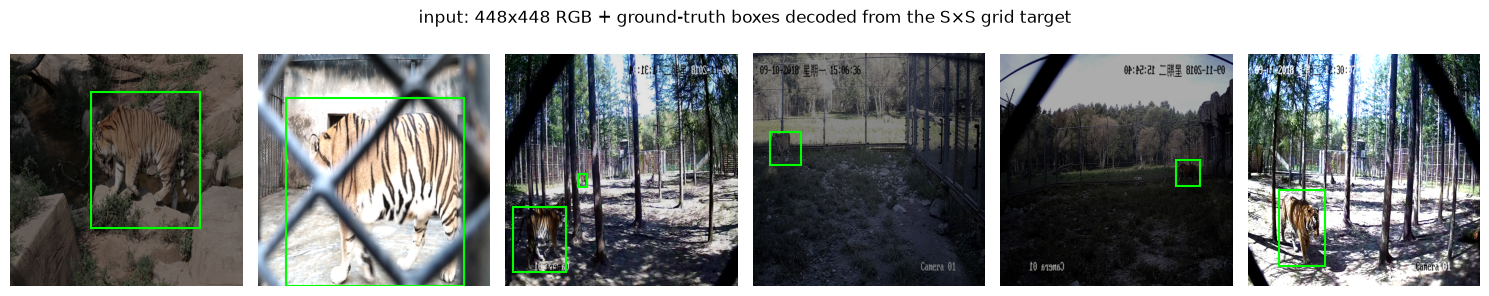

In [5]:
# Look at what we're feeding the network: images + the ground-truth boxes decoded from the grid.
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def unnormalize(img):
    """(3,H,W) normalized tensor -> (H,W,3) array in 0..1, for display only."""
    mean = torch.tensor(NORM_MEAN).view(3, 1, 1)
    std = torch.tensor(NORM_STD).view(3, 1, 1)
    return (img * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()


fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for ax, img, tgt in zip(axes, xb, yb):
    ax.imshow(unnormalize(img))
    for x0, y0, x1, y1 in grid_to_boxes(tgt):
        ax.add_patch(patches.Rectangle((x0, y0), x1 - x0, y1 - y0,
                                        fill=False, edgecolor="lime", linewidth=1.5))
    ax.axis("off")
plt.suptitle("input: 448x448 RGB + ground-truth boxes decoded from the S×S grid target")
plt.tight_layout(); plt.show()


# Section 2 — Helper functions, and why each exists

Detection needs a few more helpers than classification: boxes don't compare with `==`, they compare
by **overlap**. The first group below is the usual capacity/shape/history toolbox from `n1`–`n4`; the
second is specific to turning raw grid predictions into actual boxes.


In [6]:
def count_params(model):
    """WHY: capacity vs. speed, same trade-off as every other network in this series."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def box_iou(boxes1, boxes2):
    """WHY: the one way to compare two boxes. Corner-format (x0,y0,x1,y1), broadcasts over
    any matching leading dims — used both inside the loss and during NMS/evaluation."""
    x0 = torch.maximum(boxes1[..., 0], boxes2[..., 0])
    y0 = torch.maximum(boxes1[..., 1], boxes2[..., 1])
    x1 = torch.minimum(boxes1[..., 2], boxes2[..., 2])
    y1 = torch.minimum(boxes1[..., 3], boxes2[..., 3])
    inter = (x1 - x0).clamp(min=0) * (y1 - y0).clamp(min=0)
    area1 = (boxes1[..., 2] - boxes1[..., 0]).clamp(min=0) * (boxes1[..., 3] - boxes1[..., 1]).clamp(min=0)
    area2 = (boxes2[..., 2] - boxes2[..., 0]).clamp(min=0) * (boxes2[..., 3] - boxes2[..., 1]).clamp(min=0)
    return inter / (area1 + area2 - inter + 1e-8)


def cell_boxes_to_corners(x, y, w, h, col, row, size=IMG_SIZE):
    """WHY: predictions and targets live in cell-relative (x,y,w,h) space; IOU and NMS need
    pixel corners. One shared decoder keeps the loss and the inference path consistent."""
    xc = (col + x) * CELL
    yc = (row + y) * CELL
    bw, bh = w.clamp(min=0) * size, h.clamp(min=0) * size
    return torch.stack([xc - bw / 2, yc - bh / 2, xc + bw / 2, yc + bh / 2], dim=-1)


@torch.no_grad()
def show_shapes(model, size=IMG_SIZE, channels=3):
    """WHY: verify shape flow through the conv stack and confirm it lands on S=7 before the head."""
    x = torch.zeros(1, channels, size, size, device=DEVICE)
    print(f"{'input':28} {tuple(x.shape)}")

    hooks = []

    def register(name, module):
        if len(list(module.children())) == 0:
            def hook(_m, _in, out):
                del _m, _in
                if isinstance(out, torch.Tensor):
                    print(f"{name:28} {tuple(out.shape)}")
            hooks.append(module.register_forward_hook(hook))

    for name, module in model.named_modules():
        register(name, module)

    model.eval()
    _ = model(x)

    for h in hooks:
        h.remove()


def plot_history(history):
    """WHY: loss shape tells you if optimization is working; val mAP is the metric that matters."""
    _, ax = plt.subplots(1, 2, figsize=(11, 3.5))
    ax[0].plot([h["train_loss"] for h in history], marker="o")
    ax[0].set_title("training loss (Eq. 3)"); ax[0].set_xlabel("epoch")
    ax[1].plot([h["val_map"] for h in history], marker="o", color="tab:orange")
    ax[1].set_title("held-out AP@0.5 for Tiger"); ax[1].set_xlabel("epoch")
    plt.tight_layout(); plt.show()


In [7]:
def decode_predictions(preds, conf_thresh=0.2, size=IMG_SIZE):
    """
    Model output (N,S,S,B*5+C) -> per-image (boxes, scores) in pixel space, NOT yet NMS'd.
    Score = confidence * class probability (paper Eq. 1) — with C=1 this is "how sure, and
    is it actually a Tiger" collapsed into one number used to rank and threshold detections.
    """
    n = preds.shape[0]
    device = preds.device
    rows = torch.arange(S, device=device).view(1, S, 1).expand(n, S, S)
    cols = torch.arange(S, device=device).view(1, 1, S).expand(n, S, S)

    pred_boxes = preds[..., :B * 5].view(n, S, S, B, 5)
    class_prob = preds[..., B * 5:]

    results = []
    for i in range(n):
        boxes_i, scores_i = [], []
        for k in range(B):
            x, y, w, h, conf = pred_boxes[i, ..., k, :].unbind(-1)
            score = conf.clamp(min=0) * class_prob[i, ..., 0].clamp(min=0)
            keep = score > conf_thresh
            if keep.any():
                corners = cell_boxes_to_corners(x[keep], y[keep], w[keep], h[keep],
                                                 cols[i][keep], rows[i][keep], size=size)
                boxes_i.append(corners)
                scores_i.append(score[keep])
        if boxes_i:
            results.append((torch.cat(boxes_i), torch.cat(scores_i)))
        else:
            results.append((torch.empty(0, 4), torch.empty(0)))
    return results


def non_max_suppression(boxes, scores, iou_thresh=0.5):
    """Greedy NMS (paper Sec 2.3): keep the highest-confidence box, drop overlapping ones, repeat.
    Not critical to YOLO's accuracy (the grid already discourages duplicates) but the paper notes
    it still adds 2-3% mAP by cleaning up boxes near cell borders."""
    order = scores.argsort(descending=True)
    keep = []
    while order.numel() > 0:
        i = order[0].item()
        keep.append(i)
        if order.numel() == 1:
            break
        rest = order[1:]
        ious = box_iou(boxes[i].unsqueeze(0), boxes[rest])
        order = rest[ious.squeeze(0) <= iou_thresh]
    return keep


@torch.no_grad()
def mean_average_precision(model, loader, iou_thresh=0.5, conf_thresh=0.2):
    """
    VOC-style AP for the single 'Tiger' class: gather every detection across the loader (after
    NMS), sort by confidence, and integrate precision over recall using 11-point interpolation
    (the PASCAL VOC 2007-era metric the paper reports mAP against in Table 1). With C=1, mAP = AP.
    """
    model.eval()
    all_scores, all_correct = [], []
    n_gt = 0

    for x, y in loader:
        preds = model(x.to(DEVICE))
        decoded = decode_predictions(preds.cpu(), conf_thresh=conf_thresh)
        for b in range(x.shape[0]):
            gt_boxes = grid_to_boxes(y[b])
            n_gt += len(gt_boxes)
            boxes, scores = decoded[b]
            if boxes.numel() == 0:
                continue
            keep = non_max_suppression(boxes, scores, iou_thresh=iou_thresh)
            boxes, scores = boxes[keep], scores[keep]

            matched = [False] * len(gt_boxes)
            order = scores.argsort(descending=True)
            for idx in order:
                box = boxes[idx]
                best_iou, best_j = 0.0, -1
                for j, gt in enumerate(gt_boxes):
                    if matched[j]:
                        continue
                    iou = box_iou(box.unsqueeze(0), torch.tensor(gt).unsqueeze(0)).item()
                    if iou > best_iou:
                        best_iou, best_j = iou, j
                correct = best_iou >= iou_thresh
                if correct:
                    matched[best_j] = True
                all_scores.append(scores[idx].item())
                all_correct.append(correct)

    if n_gt == 0 or not all_scores:
        return 0.0

    order = sorted(range(len(all_scores)), key=lambda i: -all_scores[i])
    tp = torch.tensor([all_correct[i] for i in order], dtype=torch.float32)
    fp = 1 - tp
    tp_cum, fp_cum = torch.cumsum(tp, 0), torch.cumsum(fp, 0)
    recall = tp_cum / n_gt
    precision = tp_cum / (tp_cum + fp_cum)

    ap = 0.0
    for t in torch.linspace(0, 1, 11):
        p = precision[recall >= t]
        ap += (p.max().item() if p.numel() else 0.0) / 11
    return ap


# Section 3 — The architecture

## The shape of the idea

Classification asks "what is this image." Detection asks "what, and **where**, and **how many**."
YOLO answers all three with one forward pass by dividing the image into an S×S grid and letting each
cell vote:

$$
\text{output} \in \mathbb{R}^{S \times S \times (B \cdot 5 + C)}
$$

Each cell predicts:
- **B boxes**, each an $(x, y, w, h, \text{confidence})$ tuple. $(x,y)$ = box center as an offset
  *inside the cell* (0..1); $(w,h)$ = box size as a fraction of the *whole image*. Confidence
  $= \Pr(\text{object}) \cdot \text{IOU}^{\text{truth}}_{\text{pred}}$ (paper Sec 2).
- **C class probabilities**, conditioned on an object being present — here just
  $\Pr(\text{Tiger}\mid\text{object})$.

With $S=7$, $B=2$, $C=1$: a $7 \times 7 \times 11$ tensor. On PASCAL VOC the paper uses $C=20$ for a
$7\times7\times30$ tensor — the grid and box math are identical, only $C$ shrinks.

## The layers (Fast YOLO style — 9 conv layers)

| Stage | What it is | In → Out | Why |
|---|---|---|---|
| block1 | 3×3 conv 16 + BN + leaky ReLU + 2×2 max-pool | 3×448×448 → 16×224×224 | early edge features + downsample |
| block2 | 3×3 conv 32 + max-pool | 16×224×224 → 32×112×112 | |
| block3 | 3×3 conv 64 + max-pool | 32×112×112 → 64×56×56 | |
| block4 | 3×3 conv 128 + max-pool | 64×56×56 → 128×28×28 | |
| block5 | 3×3 conv 256 + max-pool | 128×28×28 → 256×14×14 | |
| block6 | 3×3 conv 512 + max-pool | 256×14×14 → 512×7×7 | grid resolution reached: S=7 |
| block7–9 | three 3×3 conv 1024, no pooling | 512×7×7 → 1024×7×7 | deepen features at fixed grid size |
| head | flatten → FC 1024 → dropout(0.5) → FC (S·S·(B·5+C)) → reshape | 1024×7×7 → 7×7×11 | one prediction per cell |

Every conv is followed by BatchNorm + **leaky ReLU (slope 0.1)** — the paper's Eq. (2) activation.
The final FC layer is followed by a **sigmoid**, not the paper's plain linear output (see the
adaptation note above) — it keeps every one of the 11 values per cell in [0,1], which is exactly
where the paper's own normalization already puts x, y, w, h and confidence (Sec 2.2).


In [8]:
class ConvBlock(nn.Module):
    """conv -> BN -> leaky ReLU(0.1) -> [optional 2x2 max-pool]. The paper's Eq. (2) activation."""

    def __init__(self, in_ch, out_ch, pool=True):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
        self.act = nn.LeakyReLU(0.1, inplace=True)
        self.pool = nn.MaxPool2d(2, 2) if pool else nn.Identity()

    def forward(self, x):
        return self.pool(self.act(self.bn(self.conv(x))))


class FastYOLO(nn.Module):
    """Paper's 'Fast YOLO': 9 conv layers, fewer filters than the 24-layer full network (Sec 2.1)."""

    def __init__(self, s=7, b=2, c=1):
        super().__init__()
        self.s, self.b, self.c = s, b, c
        self.features = nn.Sequential(
            ConvBlock(3, 16),
            ConvBlock(16, 32),
            ConvBlock(32, 64),
            ConvBlock(64, 128),
            ConvBlock(128, 256),
            ConvBlock(256, 512),
            ConvBlock(512, 1024, pool=False),
            ConvBlock(1024, 1024, pool=False),
            ConvBlock(1024, 1024, pool=False),
        )
        out_dim = s * s * (b * 5 + c)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1024 * s * s, 1024),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, out_dim),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.head(x)
        # Sigmoid, not linear (paper's literal choice) -- see the adaptation note above:
        # bounds every value to [0,1], which is where x,y,w,h,confidence already live by
        # the paper's own normalization, and keeps training stable from random init.
        x = torch.sigmoid(x)
        return x.view(-1, self.s, self.s, self.b * 5 + self.c)


model = FastYOLO(s=S, b=B, c=C).to(DEVICE)
print(model)
print("\ntrainable parameters:", count_params(model), "(Fast YOLO style)")


FastYOLO(
  (features): Sequential(
    (0): ConvBlock(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (act): LeakyReLU(negative_slope=0.1, inplace=True)
      (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): ConvBlock(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (act): LeakyReLU(negative_slope=0.1, inplace=True)
      (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): ConvBlock(
      (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (act): Lea

In [9]:
# Watch the tensor flow through the conv stack and confirm it lands on 7x7 before the head.
show_shapes(model);


input                        (1, 3, 448, 448)
features.0.conv              (1, 16, 448, 448)
features.0.bn                (1, 16, 448, 448)
features.0.act               (1, 16, 448, 448)
features.0.pool              (1, 16, 224, 224)
features.1.conv              (1, 32, 224, 224)
features.1.bn                (1, 32, 224, 224)
features.1.act               (1, 32, 224, 224)
features.1.pool              (1, 32, 112, 112)
features.2.conv              (1, 64, 112, 112)
features.2.bn                (1, 64, 112, 112)
features.2.act               (1, 64, 112, 112)
features.2.pool              (1, 64, 56, 56)
features.3.conv              (1, 128, 56, 56)
features.3.bn                (1, 128, 56, 56)
features.3.act               (1, 128, 56, 56)
features.3.pool              (1, 128, 28, 28)
features.4.conv              (1, 256, 28, 28)
features.4.bn                (1, 256, 28, 28)
features.4.act               (1, 256, 28, 28)
features.4.pool              (1, 256, 14, 14)
features.5.conv         

## What one training step actually does

Five lines, run once per batch — same shape as every other notebook in this series; only the loss
function is new.

```python
preds = model(x)                       # 1. FORWARD
loss  = yolo_loss(preds, y)            # 2. MEASURE THE ERROR
optimizer.zero_grad()                  # 3. CLEAR OLD GRADIENTS
loss.backward()                        # 4. BACKWARD  (back-propagation)
optimizer.step()                       # 5. UPDATE THE WEIGHTS
```

**1. Forward.** The batch becomes a `(N, 7, 7, 11)` tensor: 2 candidate boxes + 1 class score, per cell.

**2. Loss — the paper's Eq. (3).** Five sum-squared terms, weighted so the network doesn't collapse
to "predict no object everywhere" (see the loss cell below for why that's a real risk).

**3–5.** Same three lines as `n1`–`n4`: zero the gradients, back-propagate, step the optimizer.

Repeat over the whole dataset = one **epoch**.


In [10]:
LAMBDA_COORD = 5.0     # paper: up-weight box-coordinate error...
LAMBDA_NOOBJ = 0.5      # ...and down-weight "no object" confidence error, since most cells are empty


def yolo_loss(preds, target):
    """
    Paper Eq. (3). preds: (N,S,S,B*5+C), target: (N,S,S,5+C).
    Without lambda weighting, the confidence loss from the many empty cells overwhelms the
    coordinate loss from the few object cells and training diverges (paper Sec 2.2) — that's
    exactly what LAMBDA_COORD / LAMBDA_NOOBJ exist to prevent.
    """
    n = preds.shape[0]
    device = preds.device
    obj_mask = target[..., 0] == 1              # (N,S,S) cells that hold an object
    noobj_mask = ~obj_mask

    rows = torch.arange(S, device=device).view(1, S, 1).expand(n, S, S)
    cols = torch.arange(S, device=device).view(1, 1, S).expand(n, S, S)

    pred_boxes = preds[..., :B * 5].view(n, S, S, B, 5)   # (N,S,S,B,5) = x,y,w,h,conf
    tgt_box = target[..., 1:5]                             # (N,S,S,4)

    # Which of the B predictors is "responsible"? Highest IOU with ground truth (paper Sec 2.2) —
    # this is what makes the two predictors specialize instead of learning the same thing.
    with torch.no_grad():
        tgt_corners = cell_boxes_to_corners(tgt_box[..., 0], tgt_box[..., 1],
                                             tgt_box[..., 2], tgt_box[..., 3], cols, rows)
        ious = torch.zeros(n, S, S, B, device=device)
        for k in range(B):
            pk = pred_boxes[..., k, :]
            pk_corners = cell_boxes_to_corners(pk[..., 0], pk[..., 1], pk[..., 2], pk[..., 3], cols, rows)
            ious[..., k] = box_iou(pk_corners, tgt_corners)
        responsible = ious.argmax(dim=-1)
        best_iou = ious.gather(-1, responsible.unsqueeze(-1)).squeeze(-1)

    resp_onehot = F.one_hot(responsible, B).bool()
    resp_box = pred_boxes[resp_onehot].view(n, S, S, 5)     # the chosen predictor's x,y,w,h,conf

    obj = obj_mask.unsqueeze(-1).float()

    # 1) box center loss (object cells only)
    xy_loss = ((resp_box[..., 0:2] - tgt_box[..., 0:2]) ** 2 * obj).sum()
    # 2) box size loss, on sqrt(w), sqrt(h) — the paper's fix so a fixed pixel error matters
    #    more on a small box than on a large one (Sec 2.2)
    wh_loss = ((torch.sqrt(resp_box[..., 2:4].clamp(min=1e-6))
                - torch.sqrt(tgt_box[..., 2:4].clamp(min=1e-6))) ** 2 * obj).sum()
    coord_loss = LAMBDA_COORD * (xy_loss + wh_loss)

    # 3) confidence loss for the responsible predictor in object cells (target = measured IOU)
    obj_conf_loss = ((resp_box[..., 4] - best_iou) ** 2 * obj_mask.float()).sum()

    # 4) confidence loss for every predictor in cells with no object (target = 0)
    noobj_loss = LAMBDA_NOOBJ * (pred_boxes[..., 4] ** 2 * noobj_mask.unsqueeze(-1).float()).sum()

    # 5) class probability loss, object cells only (C=1: "is it a Tiger")
    class_loss = ((preds[..., B * 5:] - target[..., 5:]) ** 2 * obj).sum()

    return (coord_loss + obj_conf_loss + noobj_loss + class_loss) / n


In [11]:
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3, momentum=0.9, weight_decay=5e-4)

x, y = next(iter(train_loader))
x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)

# Pick one first-layer kernel weight and watch it change.
w = model.features[0].conv.weight
before = w[0, 0, 0, 0].item()
print("gradient before backward():", w.grad)

preds = model(x)
print("prediction grid for one image:", tuple(preds[0].shape), "(7x7 cells, 11 values each)")

loss = yolo_loss(preds, y)
print("loss:", round(loss.item(), 4))

optimizer.zero_grad()
loss.backward()
print("gradient after backward():", round(w.grad[0, 0, 0, 0].item(), 6))

optimizer.step()
print(f"weight: {before:.6f} -> {w[0,0,0,0].item():.6f}  (moved against the gradient)")


gradient before backward(): None
prediction grid for one image: (7, 7, 11) (7x7 cells, 11 values each)
loss: 17.3593
gradient after backward(): 2.4e-05
weight: -0.113989 -> -0.113989  (moved against the gradient)


# Section 4 — Training

Same five lines, now in a loop over epochs.

Paper-consistent choices used here: SGD with momentum and weight decay, a linear learning-rate
warmup followed by two step drops.

The paper trains 135 epochs with LR 1e-3→1e-2 (warmup) → 1e-2 (75 epochs) → 1e-3 (30) → 1e-4 (30),
starting from a week of ImageNet-pretrained conv weights. We skip pretraining (Section 0 adaptation),
so we start further from a good solution — the schedule below keeps the same *shape* (warmup, hold,
two drops) but with fewer epochs and a lower peak LR, since a from-scratch run with no pretrained
features is more prone to diverging at the paper's original 1e-2.

For speed on GPU, mixed precision (`autocast` + `GradScaler`) is enabled automatically. Held-out AP
is recomputed every epoch — cheap here since the val set is only 277 images.


In [12]:
def fit(model, train_loader, test_loader, epochs=60, lr=1e-3, warmup_epochs=3):
    """Train the model. Returns a history list you can plot."""
    import csv, time
    from pathlib import Path

    log_path = Path("runs") / "n5_yolov1" / "history.csv"
    log_path.parent.mkdir(parents=True, exist_ok=True)

    def log_epoch_csv(rec):
        """Append one epoch's metrics as a CSV row -- survives a KeyboardInterrupt mid-training."""
        write_header = not log_path.exists()
        with open(log_path, "a", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=list(rec.keys()))
            if write_header:
                writer.writeheader()
            writer.writerow(rec)

    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
    milestones = [int(epochs * 0.6), int(epochs * 0.85)]
    scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=milestones, gamma=0.1)

    amp_enabled = DEVICE.type == "cuda"
    scaler = torch.amp.GradScaler("cuda", enabled=amp_enabled)

    history = []

    for epoch in range(1, epochs + 1):
        epoch_start = time.time()
        if epoch <= warmup_epochs:                      # linear warmup, paper Sec 2.2
            warm_lr = lr * epoch / warmup_epochs
            for g in optimizer.param_groups:
                g["lr"] = warm_lr

        model.train()
        running_loss, seen = 0.0, 0

        for x, y in train_loader:
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda", enabled=amp_enabled):
                preds = model(x)
                loss = yolo_loss(preds, y)

            scaler.scale(loss).backward()
            if amp_enabled:
                scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)  # standard safeguard,
            scaler.step(optimizer)                                             # not paper-specified
            scaler.update()

            running_loss += loss.item() * len(y)
            seen += len(y)

        if epoch > warmup_epochs:
            scheduler.step()

        val_map = mean_average_precision(model, test_loader)
        rec = {
            "epoch": epoch,
            "train_loss": running_loss / seen,
            "val_map": val_map,
            "error_rate": round(100.0 * (1.0 - val_map), 4),
            "epoch_time_sec": round(time.time() - epoch_start, 2),
            "lr": optimizer.param_groups[0]["lr"],
        }
        history.append(rec)
        log_epoch_csv(rec)
        print(
            f"epoch {epoch:2d}  lr {rec['lr']:.4g}  loss {rec['train_loss']:.4f}  "
            f"val AP@0.5 {rec['val_map']:.3f}  ({rec['epoch_time_sec']:.1f}s)"
        )

    return history


In [13]:
model = FastYOLO(s=S, b=B, c=C).to(DEVICE)     # fresh model
history = fit(model, train_loader, test_loader, epochs=30, lr=1e-3)


KeyboardInterrupt: 

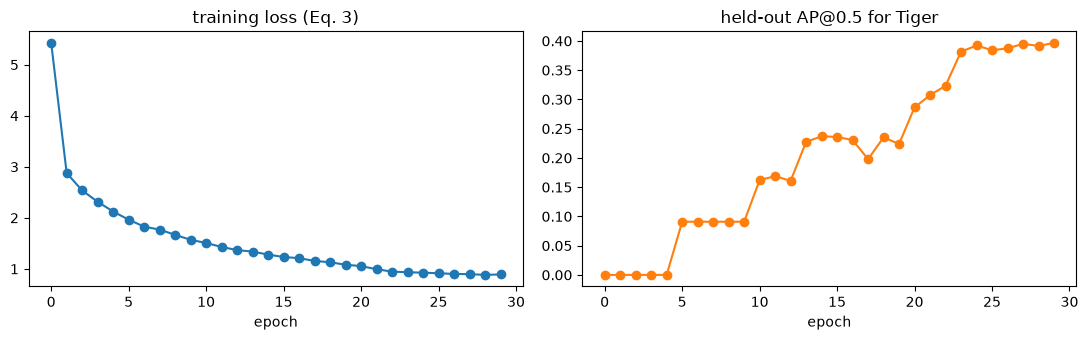

best held-out AP@0.5: 0.39653594385493884


In [ ]:
plot_history(history)
print("best held-out AP@0.5:", max(h["val_map"] for h in history))


# Section 5 — Prediction and validation

Three checks, in increasing usefulness:
1. how many boxes it finds per image, after NMS,
2. the overall held-out AP@0.5 — the paper's headline metric, collapsed to one class here,
3. *where* it draws the boxes (look at the images).

Step 3 is the one that tells you what to fix.


In [ ]:
@torch.no_grad()
def predict(model, x, conf_thresh=0.2, iou_thresh=0.5):
    """Full inference path: forward -> decode -> per-image NMS. Returns [(boxes, scores), ...]."""
    model.eval()
    preds = model(x.to(DEVICE))
    decoded = decode_predictions(preds.cpu(), conf_thresh=conf_thresh)
    results = []
    for boxes, scores in decoded:
        keep = non_max_suppression(boxes, scores, iou_thresh=iou_thresh) if boxes.numel() else []
        results.append((boxes[keep], scores[keep]))
    return results


x, y = next(iter(test_loader))
results = predict(model, x[:8])
for i in range(8):
    n_pred = len(results[i][0])
    n_true = int(y[i][..., 0].sum())
    print(f"image {i}: {n_true} true tiger(s)  ->  {n_pred} detected after NMS")


image 0: 2 true tiger(s)  ->  1 detected after NMS
image 1: 1 true tiger(s)  ->  1 detected after NMS
image 2: 4 true tiger(s)  ->  1 detected after NMS
image 3: 2 true tiger(s)  ->  0 detected after NMS
image 4: 1 true tiger(s)  ->  0 detected after NMS
image 5: 2 true tiger(s)  ->  2 detected after NMS
image 6: 1 true tiger(s)  ->  0 detected after NMS
image 7: 2 true tiger(s)  ->  2 detected after NMS


In [ ]:
# Full held-out set: AP@0.5, the paper's headline metric (collapses to one class here).
val_map = mean_average_precision(model, test_loader, iou_thresh=0.5, conf_thresh=0.2)
print(f"held-out AP@0.5 for 'Tiger': {val_map:.3f}")
print("floor for comparison: a detector that never fires (predicts nothing) scores AP = 0.000.")


held-out AP@0.5 for 'Tiger': 0.397
floor for comparison: a detector that never fires (predicts nothing) scores AP = 0.000.


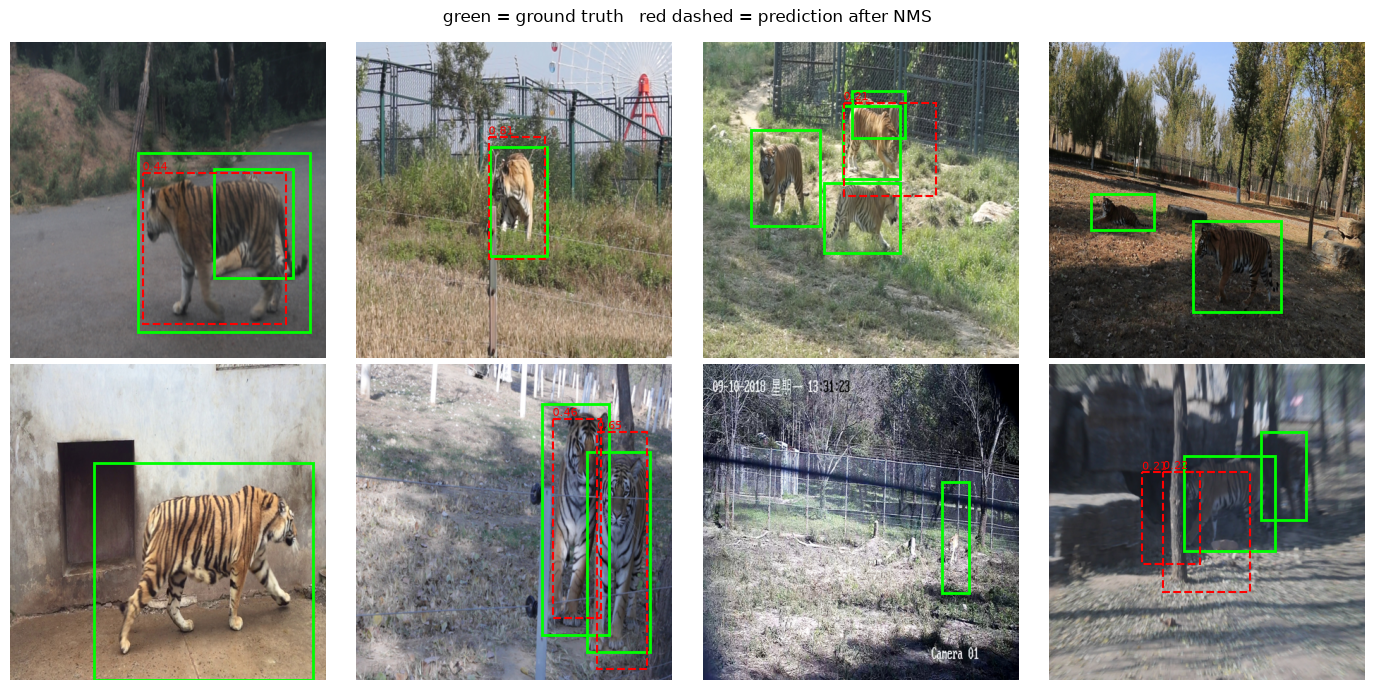

In [ ]:
# Look at where the boxes actually land: this is where localization errors become visible.
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, img, tgt, (boxes, scores) in zip(axes.ravel(), x[:8], y[:8], results):
    ax.imshow(unnormalize(img))
    for x0, y0, x1, y1 in grid_to_boxes(tgt):
        ax.add_patch(patches.Rectangle((x0, y0), x1 - x0, y1 - y0,
                                        fill=False, edgecolor="lime", linewidth=2))
    for (bx0, by0, bx1, by1), s in zip(boxes.tolist(), scores.tolist()):
        ax.add_patch(patches.Rectangle((bx0, by0), bx1 - bx0, by1 - by0,
                                        fill=False, edgecolor="red", linewidth=1.5, linestyle="--"))
        ax.text(bx0, max(by0 - 4, 0), f"{s:.2f}", color="red", fontsize=8)
    ax.axis("off")
plt.suptitle("green = ground truth   red dashed = prediction after NMS")
plt.tight_layout(); plt.show()


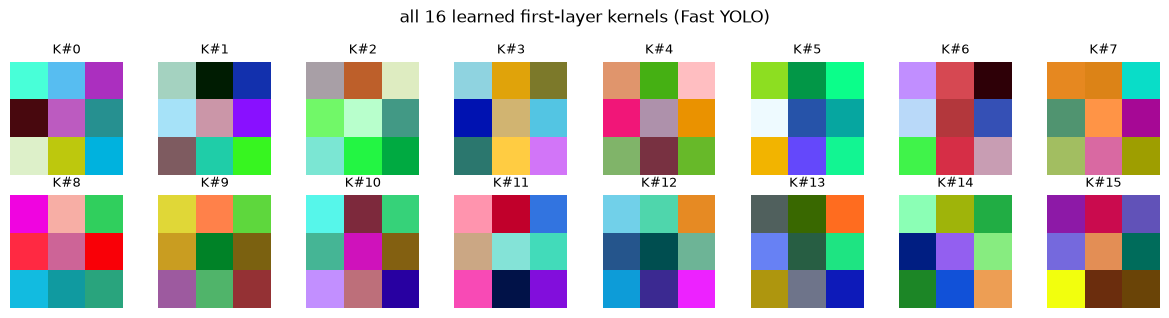

In [ ]:
# Visualize the first-layer kernels. Each 3x3x3 tile is one learned edge/colour detector.
k = model.features[0].conv.weight.detach().cpu()   # (16, 3, 3, 3)
fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for i, ax in enumerate(axes.ravel()):
    tile = k[i].permute(1, 2, 0)
    tile = (tile - tile.min()) / (tile.max() - tile.min() + 1e-8)
    ax.imshow(tile); ax.set_title(f"K#{i}", fontsize=9); ax.axis("off")
plt.suptitle("all 16 learned first-layer kernels (Fast YOLO)")
plt.tight_layout(); plt.show()


# Section 6 — Glossary

**Bounding box** — $(x, y, w, h)$: the rectangle drawn around one object.

**Grid cell / "responsible" cell** — YOLO splits the image into an S×S grid; whichever cell contains
an object's center is responsible for predicting it (paper Sec 2).

**Confidence score** — $\Pr(\text{object}) \times \text{IOU}^{\text{truth}}_{\text{pred}}$: how sure
the model is *and* how good the box is, folded into one number.

**Class-specific confidence** — confidence × class probability (paper Eq. 1); the score detections
are ranked and thresholded by.

**IOU (Intersection over Union)** — overlap area ÷ union area of two boxes; the standard measure of
how well two boxes agree.

**Responsible predictor** — of the B boxes a cell predicts, the one with highest IOU to the ground
truth is trained to match it; the other predictor(s) only get pushed toward zero confidence.

**Non-max suppression (NMS)** — greedily keep the highest-confidence box, discard other boxes that
overlap it past a threshold, repeat. Cleans up near-duplicate detections at cell borders.

**Localization error** vs **classification error** — did the box miss the object (bad coordinates),
or misname it (bad class)? Paper Sec 4.2 splits YOLO's mistakes this way.

**Precision** — of the boxes predicted, what fraction are correct.
**Recall** — of the true objects, what fraction were found.

**Average Precision (AP)** — area under the precision-recall curve for one class, at a fixed IOU
threshold (here 0.5). **mAP** — AP averaged over classes; with C=1 here, mAP = AP for "Tiger".

**11-point interpolated AP** — the PASCAL VOC 2007-era way of turning a precision-recall curve into
one number; the metric the paper's Table 1/3 report against.

**Tensor** — an n-dimensional array. An image batch is a 4-D tensor `(batch, channels, height, width)`.

**Convolution / stride / padding** — sliding a kernel across the image; how far it moves each step;
extra border pixels controlling output size.

**Batch normalization (BN)** — normalizes activations to stabilize and accelerate optimization.

**Leaky ReLU** — $\phi(x) = x$ if $x>0$ else $0.1x$ (paper Eq. 2); avoids the "dead neuron" problem
of standard ReLU.

**Loss function** — one scalar measuring prediction error; here the multi-part sum-squared loss
(paper Eq. 3) instead of cross-entropy, since we're regressing coordinates, not just classifying.

**Gradient / back-propagation / optimizer / weight decay / learning-rate schedule** — same meaning
as in `n1`–`n4`: derivative of loss w.r.t. parameters; the chain rule used to compute them; SGD with
momentum as the update rule; L2 penalty on large weights; scheduled LR changes during training.

**Epoch / batch** — one full pass over training data / one subset processed before an update.

**Overfitting** — strong training performance but weak held-out AP.

**`model.train()` / `model.eval()`** — switches training/inference behavior (BN and dropout differ).

**`zero_grad()` / `torch.no_grad()`** — clears accumulated gradients before backward / disables
gradient tracking during evaluation for speed and memory.


## Next steps

Change one thing, re-run `fit`, compare held-out AP@0.5:

| Try | What it tells you |
|---|---|
| train the full 24-conv YOLO instead of Fast YOLO | whether the extra depth/width raises AP on this dataset |
| pretrain the conv backbone (e.g. on the ATRW re-ID crops from `n4`) before detection fine-tuning | whether the paper's two-stage recipe closes the from-scratch gap |
| add the paper's random scale/translate augmentation, not just flip + color jitter | whether geometric augmentation improves localization specifically |
| lower `conf_thresh` / tune `iou_thresh` in NMS | the precision/recall trade-off at inference time |
| push `epochs` toward the paper's 135 | whether AP is still climbing or has already plateaued |
| try a finer grid, e.g. S=13 | whether it helps with frames holding many tigers close together |

Change **one** at a time and log the result. That isolates what actually helped.


## Save results

Persist the trained model and validation metrics to `runs/<name>/`, so this run survives a kernel restart and can be compared against the other notebooks later.


In [ ]:
# Save the trained model + validation results into runs/n5_yolov1/, so this run isn't lost.
import json
from pathlib import Path

RUN_DIR = Path("runs") / "n5_yolov1"
RUN_DIR.mkdir(parents=True, exist_ok=True)

torch.save({"model_state": model.state_dict(), "history": history}, RUN_DIR / "model.pt")

with open(RUN_DIR / "metrics.json", "w") as f:
    json.dump({
        "held_out_ap50": val_map,
        "best_val_ap50_during_training": max(h["val_map"] for h in history) if history else None,
        "history": history,
    }, f, indent=2)

print("saved model + metrics to", RUN_DIR.resolve())


saved model + metrics to C:\Users\eeuma\Desktop\PhD Research Codes\5_systematically_move_to_best_architecture\runs\n5_yolov1
